# Example Usage: Inference-Only Pipeline on Holdout Data

This notebook reuses the project `ml/` code (no training) to:

1. Load and inspect `hold_out_test_data`
2. Show image examples from the initial dataset
3. Show LAB-normalized examples using `ml.preprocess.preprocess`
4. Show a `DataLoader` example
5. Run full inference on holdout data with ensemble and per-model metrics
6. Show 5 concrete visual examples with side-by-side original and normalized images


In [ ]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import random

import numpy as np
import torch
from PIL import Image, ImageOps, ImageDraw
from torch.utils.data import Dataset, DataLoader
from IPython.display import display, Markdown


from ml.classify import classify
from ml.pretty_print import to_pretty_print
from ml.preprocess import preprocess
from ml.labels import CLASS_NAMES, class_index

In [8]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "hold_out_test_data"

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Missing data folder: {DATA_ROOT}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Class count (model labels): {len(CLASS_NAMES)}")

Project root: /Users/naraptis/Desktop/BloodyFlask
Data root: /Users/naraptis/Desktop/BloodyFlask/hold_out_test_data
Class count (model labels): 16


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def all_image_paths(data_root: Path) -> list[Path]:
    paths = [
        path for path in data_root.rglob("*")
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    paths.sort()
    return paths


def class_name_from_path(path: Path) -> str:
    return path.parent.name.strip().lower()


def ensure_rgb(image: Image.Image) -> Image.Image:
    if image.mode != "RGB":
        return image.convert("RGB")
    return image


def resize_for_preview(image: Image.Image, size: int = 224) -> Image.Image:
    return ImageOps.fit(ensure_rgb(image), (size, size), method=Image.Resampling.BILINEAR)

def make_grid(images: list[Image.Image], labels: list[str], columns: int = 4, cell_size: int = 220, pad: int = 10) -> Image.Image:
    rows = (len(images) + columns - 1) // columns
    title_height = 28
    canvas_width = columns * cell_size + (columns + 1) * pad
    canvas_height = rows * (cell_size + title_height) + (rows + 1) * pad
    canvas = Image.new("RGB", (canvas_width, canvas_height), color=(20, 24, 32))
    draw = ImageDraw.Draw(canvas)

    for index, image in enumerate(images):
        row = index // columns
        col = index % columns
        x = pad + col * (cell_size + pad)
        y = pad + row * (cell_size + title_height + pad)
        tile = ImageOps.fit(ensure_rgb(image), (cell_size, cell_size), method=Image.Resampling.BILINEAR)
        canvas.paste(tile, (x, y))
        draw.text((x, y + cell_size + 6), labels[index], fill=(235, 240, 250))

    return canvas

def make_comparison_canvas(original: Image.Image, normalized: Image.Image) -> Image.Image:
    canvas = Image.new("RGB", (830, 420), color=(16, 20, 32))
    left_tile = ImageOps.fit(ensure_rgb(original), (400, 400), method=Image.Resampling.BILINEAR)
    right_tile = ImageOps.fit(ensure_rgb(normalized), (400, 400), method=Image.Resampling.BILINEAR)
    canvas.paste(left_tile, (10, 10))
    canvas.paste(right_tile, (420, 10))
    return canvas


def top_prediction(probabilities_by_index: np.ndarray) -> tuple[str, float]:
    top_index = int(np.argmax(probabilities_by_index))
    return CLASS_NAMES[top_index], float(probabilities_by_index[top_index])


all_paths = all_image_paths(DATA_ROOT)
print(f"Total holdout images: {len(all_paths)}")


Total holdout images: 3452


In [10]:
counts = defaultdict(int)
for path in all_paths:
    counts[class_name_from_path(path)] += 1

summary_rows = sorted(counts.items(), key=lambda pair: pair[0])
for class_name, count in summary_rows:
    print(f"{class_name:28s} {count}")

print(f"Total classes found in holdout folder: {len(summary_rows)}")


basophil                     93
eosinophil                   300
hairy_cell                   300
lymphocyte                   300
lymphocyte_large_granular    278
lymphocyte_neoplastic        28
metamyelocyte                73
monocyte                     300
myeloblast                   300
myelocyte                    113
neutrophil_band              104
neutrophil_segmented         300
normoblast                   300
plasma_cell                  250
promyelocyte                 113
promyelocyte_atypical        300
Total classes found in holdout folder: 16


## Initial Dataset Samples

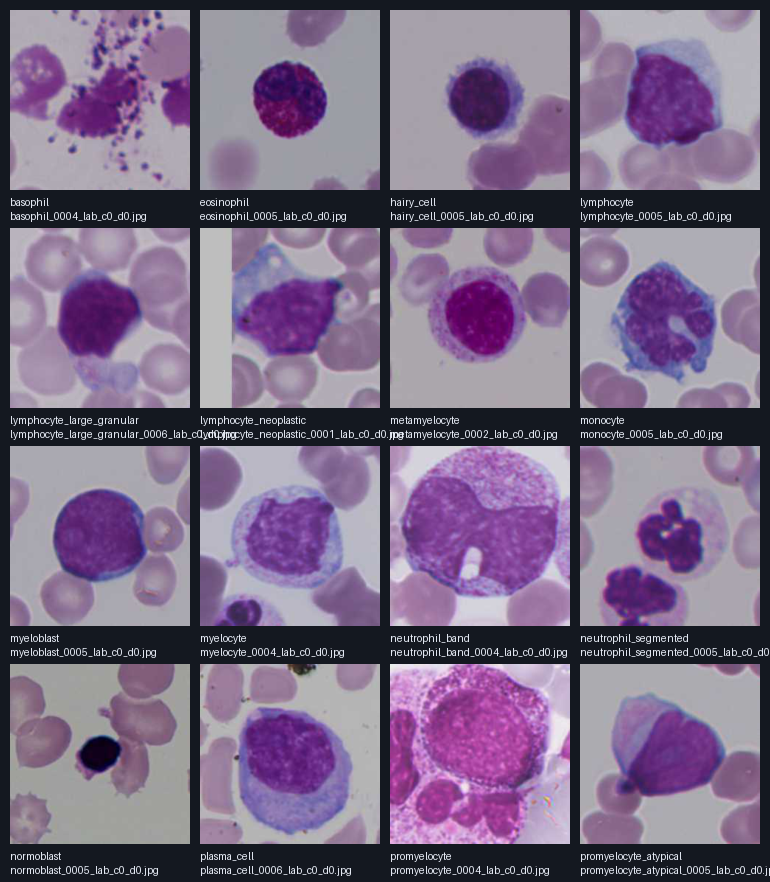

In [12]:
random.seed(13)

sampled_by_class = []
for class_name in sorted(counts.keys()):
    class_paths = [path for path in all_paths if class_name_from_path(path) == class_name]
    if class_paths:
        sampled_by_class.append(class_paths[0])

sample_images = [Image.open(path).convert("RGB") for path in sampled_by_class]
sample_labels = [f"{class_name_from_path(path)}\n{path.name}" for path in sampled_by_class]

display(make_grid(sample_images, sample_labels, columns=4, cell_size=180, pad=10))

## Initial Dataset Samples With LAB Normalization (via `preprocess.py`)

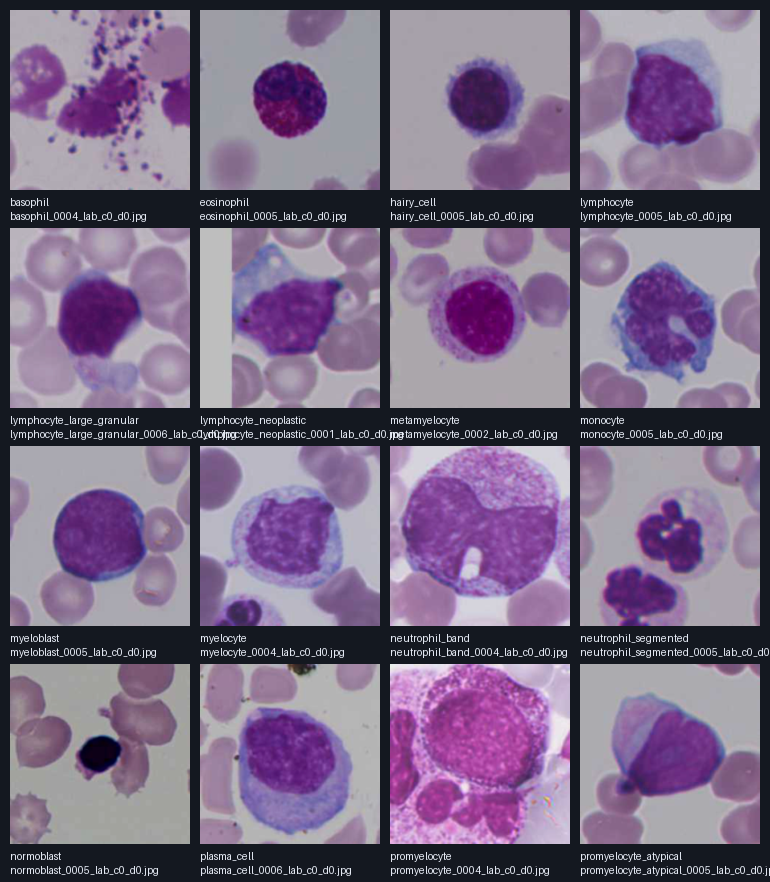

In [ ]:
normalized_images = [preprocess(image=image, normalize=True) for image in sample_images]
display(make_grid(normalized_images, sample_labels, columns=4, cell_size=180, pad=10))

## DataLoader Example

In [14]:
class HoldoutDataset(Dataset):
    def __init__(self, image_paths: list[Path], apply_lab_normalization: bool = True):
        self.image_paths = image_paths
        self.apply_lab_normalization = apply_lab_normalization

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int):
        path = self.image_paths[index]
        image = Image.open(path).convert("RGB")
        model_input = preprocess(image=image, normalize=self.apply_lab_normalization)
        array = np.asarray(model_input, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(np.transpose(array, (2, 0, 1)))
        label_name = class_name_from_path(path)
        label_index = class_index(label_name)
        return tensor, label_index, str(path)


dataset = HoldoutDataset(all_paths, apply_lab_normalization=True)
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)

batch_tensors, batch_labels, batch_paths = next(iter(loader))
print("Batch tensor shape:", tuple(batch_tensors.shape))
print("Batch labels shape:", tuple(batch_labels.shape))
print("First 3 paths:")
for sample_path in batch_paths[:3]:
    print(" -", sample_path)


Batch tensor shape: (8, 3, 224, 224)
Batch labels shape: (8,)
First 3 paths:
 - /Users/naraptis/Desktop/BloodyFlask/hold_out_test_data/myeloblast/myeloblast_0437_lab_c0_d0.jpg
 - /Users/naraptis/Desktop/BloodyFlask/hold_out_test_data/promyelocyte_atypical/promyelocyte_atypical_1517_lab_c0_d0.jpg
 - /Users/naraptis/Desktop/BloodyFlask/hold_out_test_data/normoblast/normoblast_1790_lab_c0_d0.jpg


## Holdout Inference (Reuse `ml/` Pipeline, No Training)

In [15]:
@dataclass
class EvalRow:
    path: str
    true_class: str
    ensemble_top_class: str
    ensemble_top_probability: float
    per_model_top: dict[str, tuple[str, float]]


def evaluate_holdout(image_paths: list[Path], normalize: bool = True) -> tuple[list[EvalRow], dict[str, float]]:
    rows: list[EvalRow] = []

    model_names = [
        "falcon_gold",
        "falcon_silver",
        "falcon_bronze",
        "iguana_gold",
        "iguana_silver",
        "iguana_bronze",
    ]

    ensemble_correct = 0
    model_correct = {name: 0 for name in model_names}

    for index, path in enumerate(image_paths):
        image = Image.open(path).convert("RGB")
        true_class = class_name_from_path(path)

        result = classify(image=image, normalize=normalize)

        ensemble_class, ensemble_probability = top_prediction(result.ensemble_mean.probabilities_by_index)
        if ensemble_class == true_class:
            ensemble_correct += 1

        per_model_top: dict[str, tuple[str, float]] = {}
        for model_name in model_names:
            model_class, model_probability = top_prediction(result.member(model_name).probabilities_by_index)
            per_model_top[model_name] = (model_class, model_probability)
            if model_class == true_class:
                model_correct[model_name] += 1

        rows.append(
            EvalRow(
                path=str(path),
                true_class=true_class,
                ensemble_top_class=ensemble_class,
                ensemble_top_probability=ensemble_probability,
                per_model_top=per_model_top,
            )
        )

        if (index + 1) % 200 == 0:
            print(f"Processed {index + 1}/{len(image_paths)} images")

    total = float(len(image_paths))
    metrics = {
        "ensemble_top1_accuracy": ensemble_correct / total,
    }
    for model_name in model_names:
        metrics[f"{model_name}_top1_accuracy"] = model_correct[model_name] / total

    return rows, metrics


rows, metrics = evaluate_holdout(all_paths, normalize=True)
print("\nTop-1 accuracy summary (holdout, normalize=True):")
for key, value in metrics.items():
    print(f"{key:32s} {value:.4f}")


Processed 200/3452 images
Processed 400/3452 images
Processed 600/3452 images
Processed 800/3452 images
Processed 1000/3452 images
Processed 1200/3452 images
Processed 1400/3452 images
Processed 1600/3452 images
Processed 1800/3452 images
Processed 2000/3452 images
Processed 2200/3452 images
Processed 2400/3452 images
Processed 2600/3452 images
Processed 2800/3452 images
Processed 3000/3452 images
Processed 3200/3452 images
Processed 3400/3452 images

Top-1 accuracy summary (holdout, normalize=True):
ensemble_top1_accuracy           0.9256
falcon_gold_top1_accuracy        0.9148
falcon_silver_top1_accuracy      0.9169
falcon_bronze_top1_accuracy      0.9131
iguana_gold_top1_accuracy        0.9151
iguana_silver_top1_accuracy      0.9090
iguana_bronze_top1_accuracy      0.9177


## Five Concrete Examples (830x420 Canvas, 10px Padding and Gap)


In [ ]:
example_paths = all_paths[:5]

for path in example_paths:
    image = Image.open(path).convert("RGB")
    normalized = preprocess(image=image, normalize=True)
    canvas = make_comparison_canvas(original=image, normalized=normalized)

    display(Markdown(f"### {path.parent.name} / {path.name}"))
    display(canvas)

    result = classify(image=image, normalize=True)
    pretty = to_pretty_print(result=result, top_k_per_model=3, top_k_ensemble=5)

    display(Markdown("**Ensemble prediction (top 5):**"))
    for item in pretty.ensemble_list:
        print(f" - {item.class_name}: {item.probability * 100.0:.2f}%")

    display(Markdown("**Individual model predictions (top 3 each):**"))
    for model_name in pretty.model_list:
        print(f"\n{model_name}")
        model_result = pretty.model_result_table[model_name]
        for class_name in model_result.class_list:
            probability = model_result.class_table[class_name]
            print(f" - {class_name}: {probability * 100.0:.2f}%")

    print("\n" + "=" * 80 + "\n")


## Notes

- This notebook is inference-only and does not train or update weights.
- It reuses project code from `ml.classify`, `ml.pretty_print`, and `ml.preprocess`.